# Лабораторная работа №1
## Разведочный анализ данных. Исследование и визуализация данных

**Студент:** Рухлин А.В. 
**Группа:** ИУ5-66Б 

## Текстовое описание выбранного набора данных

Набор данных содержит информацию о **50 000 музыкальных треках**.  
Данные включают метаданные (идентификатор трека, название трека, имя исполнителя, название альбома, год выпуска, жанр) и стандартные аудио-характеристики Spotify: danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence и другие.  

- **Источник**: синтетический датасет, сгенерированный с реалистичными распределениями по жанрам и корреляциями (аналогично реальным данным Spotify Web API).  
- **Объём**: 50 000 записей, 21 признак.  
- **Пропуски**: отсутствуют (все значения non-null).  
- **Годы выпуска**: предположительно 2000–2024 (нужно проверить min/max в release_year).  
- **Жанры**: около 20 различных (поп, рок, хип-хоп, электроника, акустическая музыка и др.).  
- **Ключевая переменная**: `popularity` (популярность трека от 0 до 100, часто распределена по типу Zipf — много малопопулярных треков и мало очень популярных).  
- **Цель анализа**: изучить распределения аудио-признаков, зависимости популярности от характеристик трека и жанра, тренды по годам, корреляции между признаками (например, energy ↔ acousticness обычно сильно отрицательная).

Датасет идеально подходит для задач разведочного анализа, визуализации трендов музыки, кластеризации по настроению и прогнозирования популярности.

In [43]:
import pandas as pd

df = pd.read_csv('spotify_tracks.csv')        

print("Размерность:", df.shape)
print("\nИнформация о столбцах:")
df.info()
print("\nПервые 5 строк:")
display(df.head())
print("\nПоследние 5 строк:")
display(df.tail())
print("\nОсновные статистики числовых признаков:")
display(df.describe())
print("\nОсновные статистики категориальных признаков:")
display(df.describe(include='object'))

print("\nПропуски:\n", df.isna().sum())

Размерность: (50000, 21)

Информация о столбцах:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  str    
 1   track_name        50000 non-null  str    
 2   artist_name       50000 non-null  str    
 3   album_name        50000 non-null  str    
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  str    
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  va

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4



Последние 5 строк:


,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
49995,YfbSaX80clbVETH2XuwqNy,Falling Day,Dana Wilson,Dana's Greatest Hits,2019,pop,23,208104,False,0.803104,...,-8.086255,0.043379,0.142386,0.000000,0.073278,0.932042,121.647645,6,1,4
49996,m9aU41kHzlaRxNaLSjWxq9,Your Day - Radio Edit,Alex Rodriguez,The Song Album,2022,electronic,18,252596,True,0.675587,...,-7.428685,0.091063,0.000000,0.180916,0.210800,0.821827,146.723733,11,1,4
49997,5Fzoke0v3d9JxyvOPKiIYQ,One Dream (Remix),Skyler Martin,Volume 2,2004,electronic,18,196281,False,0.813765,...,-5.518529,0.097790,0.000000,0.176520,0.143273,0.333921,136.237658,5,1,4
49998,HjpFucZ1chj9q9kES3WNle,Wild Star (Acoustic Version),Avery Anderson,Avery's Greatest Hits,2010,rock,85,299196,True,0.696645,...,-3.458394,0.044604,0.251724,0.065019,0.167824,0.218093,137.793581,1,1,4
49999,JyaBuljD6jsTmRdpcHVgLv,Wild Wave,Drew Anderson,The Dance Album,2024,electronic,51,228944,False,0.882678,...,-1.101803,0.167578,0.000000,0.233876,0.042621,0.573851,125.906679,0,1,3



Основные статистики числовых признаков:


,release_year,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2015.853400,23.599560,209976.955080,0.626921,0.658879,-7.438755,0.076370,0.275942,0.155218,0.181120,0.581443,116.258270,5.477220,0.619900,4.042800
std,6.178209,17.912623,44881.858907,0.207513,0.212950,4.305645,0.064989,0.257911,0.235443,0.096788,0.183994,23.706129,3.598764,0.485416,0.513939
min,2000.000000,-5.000000,90000.000000,0.000000,0.000000,-27.795904,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,3.000000
25%,2012.000000,11.000000,179812.250000,0.489439,0.539592,-9.802727,0.031339,0.075444,0.000000,0.112240,0.457651,100.238179,2.000000,0.000000,4.000000
50%,2017.000000,19.000000,209886.500000,0.651486,0.683479,-6.906656,0.062609,0.198993,0.064522,0.179683,0.581160,115.325911,5.000000,1.000000,4.000000
75%,2021.000000,31.000000,240023.750000,0.783254,0.812390,-4.425697,0.098898,0.412742,0.168282,0.247669,0.708097,130.455924,9.000000,1.000000,4.000000
max,2024.000000,100.000000,403583.000000,1.000000,1.000000,0.000000,0.368468,1.000000,1.000000,0.581942,1.000000,220.000000,11.000000,1.000000,7.000000



Основные статистики категориальных признаков:


/var/folders/h_/r0h2sdx503xd1c5g9fg86prh0000gn/T/ipykernel_13551/3961873425.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,track_id,track_name,artist_name,album_name,genre
count,50000,50000,50000,50000,50000
unique,50000,2400,415,481,20
top,P3fAbnFbmOHnKYaXRvj7uf,Silent Dance,Phantom Keys,Volume 3,pop
freq,1,85,1098,3429,6786



Пропуски:
 track_id            0
track_name          0
artist_name         0
album_name          0
release_year        0
genre               0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
key                 0
mode                0
time_signature      0
dtype: int64


Раздел 3. Визуальное исследование датасета

In [15]:
%pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
%matplotlib inline


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


3. Визуальное исследование датасета

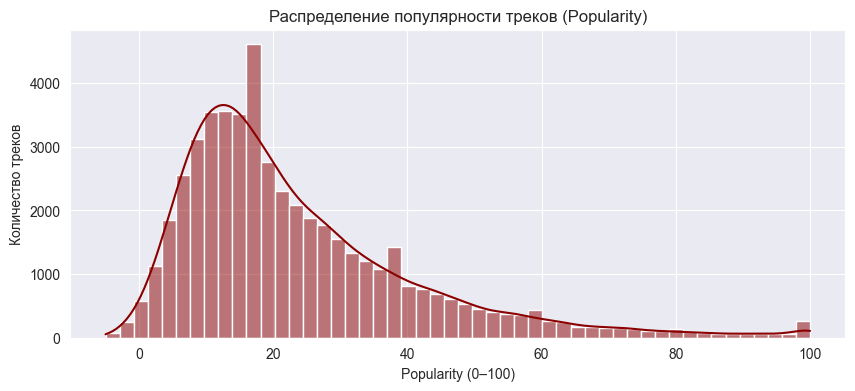

In [24]:
plt.figure(figsize=(10, 4))
sns.histplot(df['popularity'], bins=50, kde=True, color='darkred')
plt.title('Распределение популярности треков (Popularity)')
plt.xlabel('Popularity (0–100)')
plt.ylabel('Количество треков')
plt.show()

2. Гистограммы / KDE всех ключевых аудио-признаков (одним блоком)

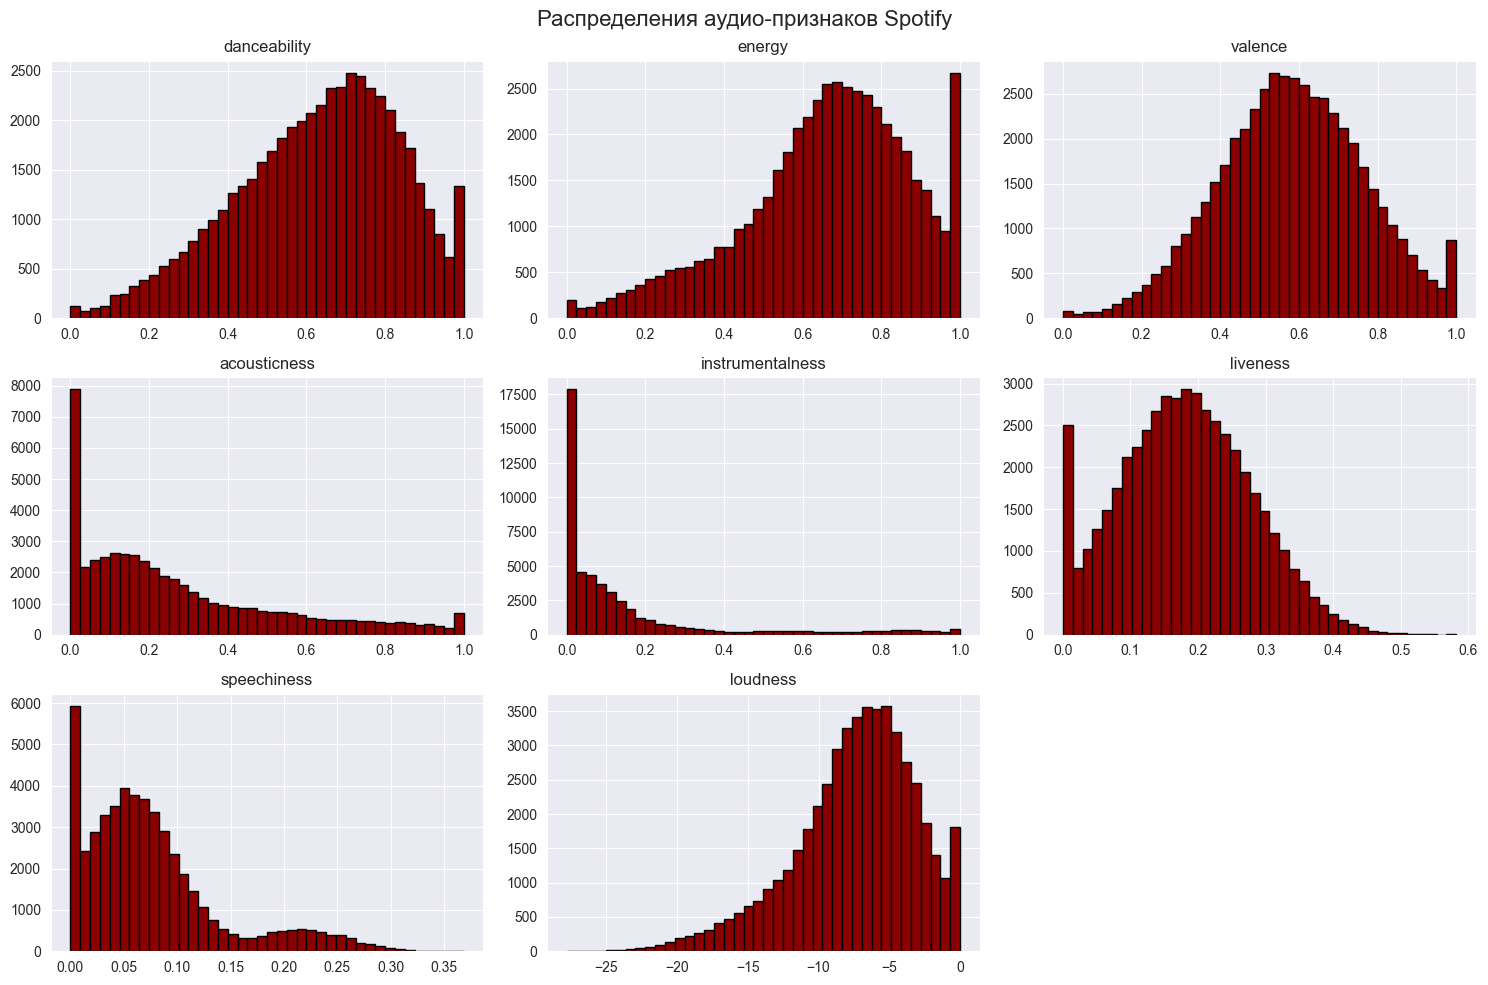

In [26]:
audio_features = ['danceability', 'energy', 'valence', 'acousticness', 
                  'instrumentalness', 'liveness', 'speechiness', 'loudness']

df[audio_features].hist(bins=40, figsize=(15, 10), color='darkred', edgecolor='black')
plt.suptitle('Распределения аудио-признаков Spotify', fontsize=16)
plt.tight_layout()
plt.show()

3. Топ-жанры по количеству треков

/var/folders/h_/r0h2sdx503xd1c5g9fg86prh0000gn/T/ipykernel_13551/4291510535.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


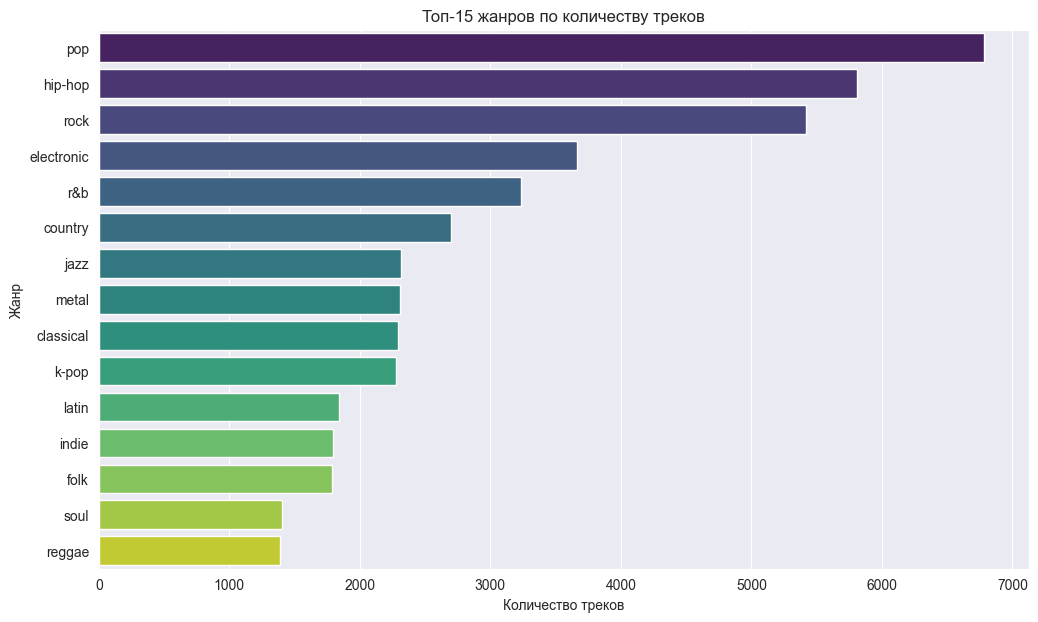

In [30]:
plt.figure(figsize=(12, 7))
genre_counts = df['genre'].value_counts().head(15)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Топ-15 жанров по количеству треков')
plt.xlabel('Количество треков')
plt.ylabel('Жанр')
plt.show()

4. Популярность по жанрам

/var/folders/h_/r0h2sdx503xd1c5g9fg86prh0000gn/T/ipykernel_13551/2064313075.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genre', y='popularity', data=df[df['genre'].isin(top_genres)],


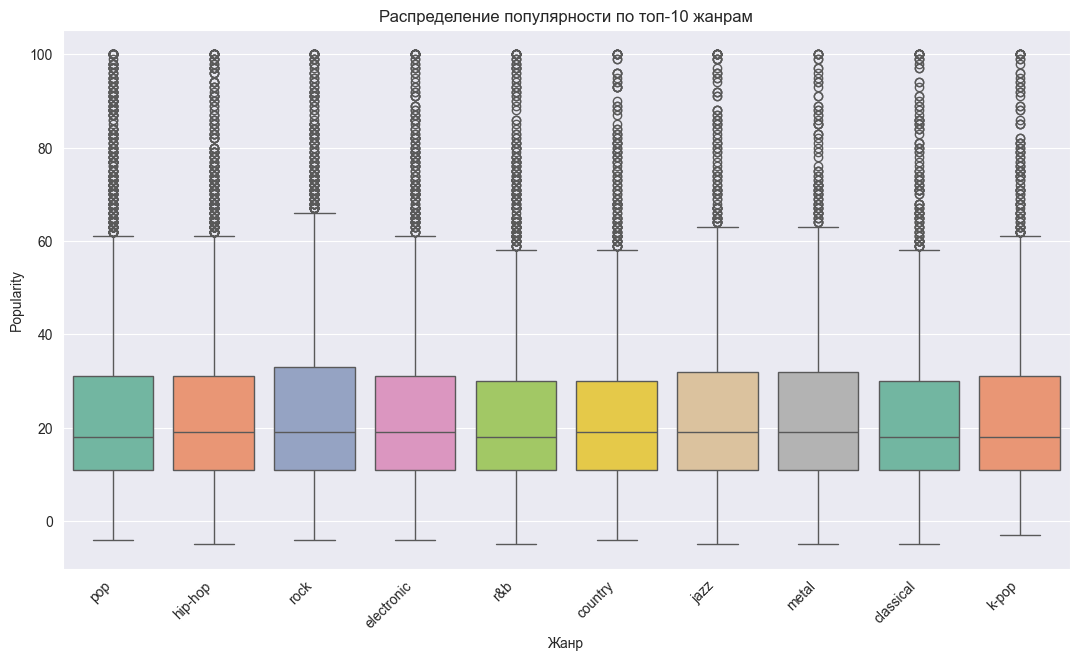

In [32]:
top_genres = df['genre'].value_counts().head(10).index

plt.figure(figsize=(13, 7))
sns.boxplot(x='genre', y='popularity', data=df[df['genre'].isin(top_genres)], 
            palette='Set2', order=top_genres)
plt.title('Распределение популярности по топ-10 жанрам')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Жанр')
plt.ylabel('Popularity')
plt.show()

5. Количество треков по годам выпуска

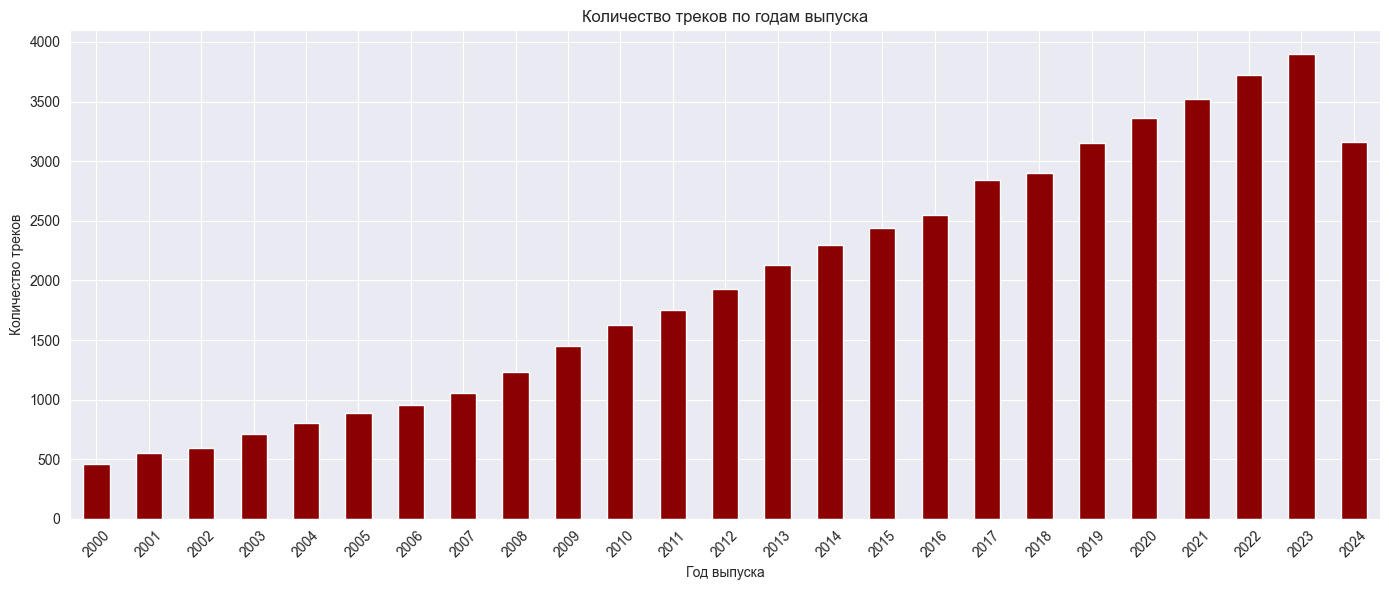

In [27]:
plt.figure(figsize=(14, 6))
year_counts = df['release_year'].value_counts().sort_index()
year_counts.plot(kind='bar', color='darkred')
plt.title('Количество треков по годам выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Количество треков')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

7. Длительность треков

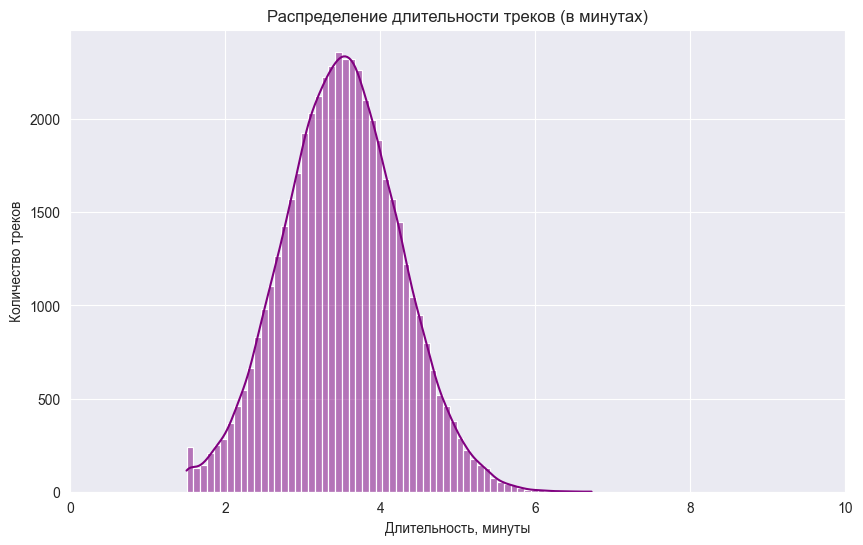

In [44]:
df['duration_min'] = df['duration_ms'] / 1000 / 60

plt.figure(figsize=(10, 6))
sns.histplot(df['duration_min'], bins=60, kde=True, color='purple')
plt.title('Распределение длительности треков (в минутах)')
plt.xlabel('Длительность, минуты')
plt.ylabel('Количество треков')
plt.xlim(0, 10) 
plt.show()

8. Pairplot (парные зависимости)

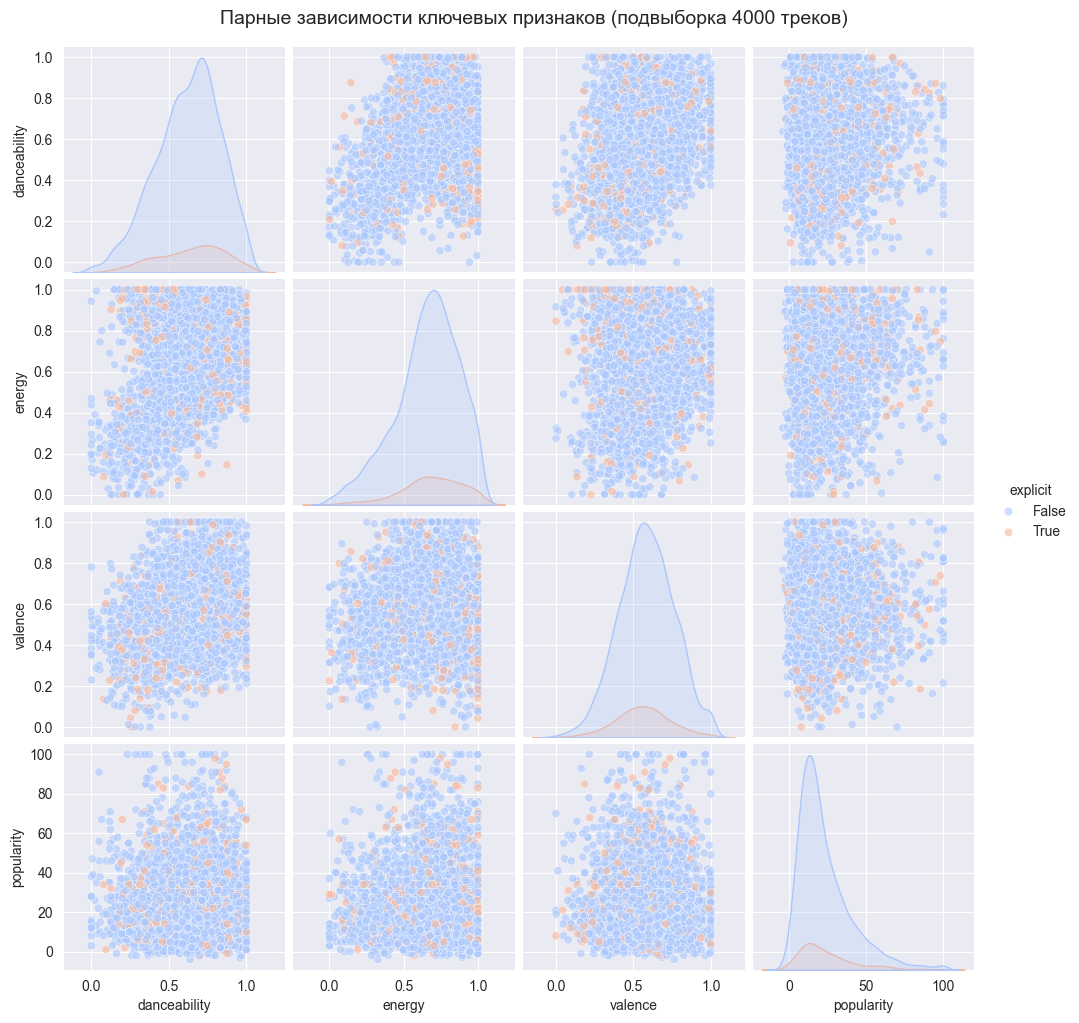

In [34]:
sample = df.sample(4000, random_state=42)

sns.pairplot(sample, 
             vars=['danceability', 'energy', 'valence', 'popularity'],
             hue='explicit', 
             diag_kind='kde',
             palette='coolwarm',
             plot_kws={'alpha':0.6})
plt.suptitle('Парные зависимости ключевых признаков (подвыборка 4000 треков)', y=1.02, fontsize=14)
plt.show()

4. Информация о корреляции признаков

# 9. Корреляционная тепловая карта

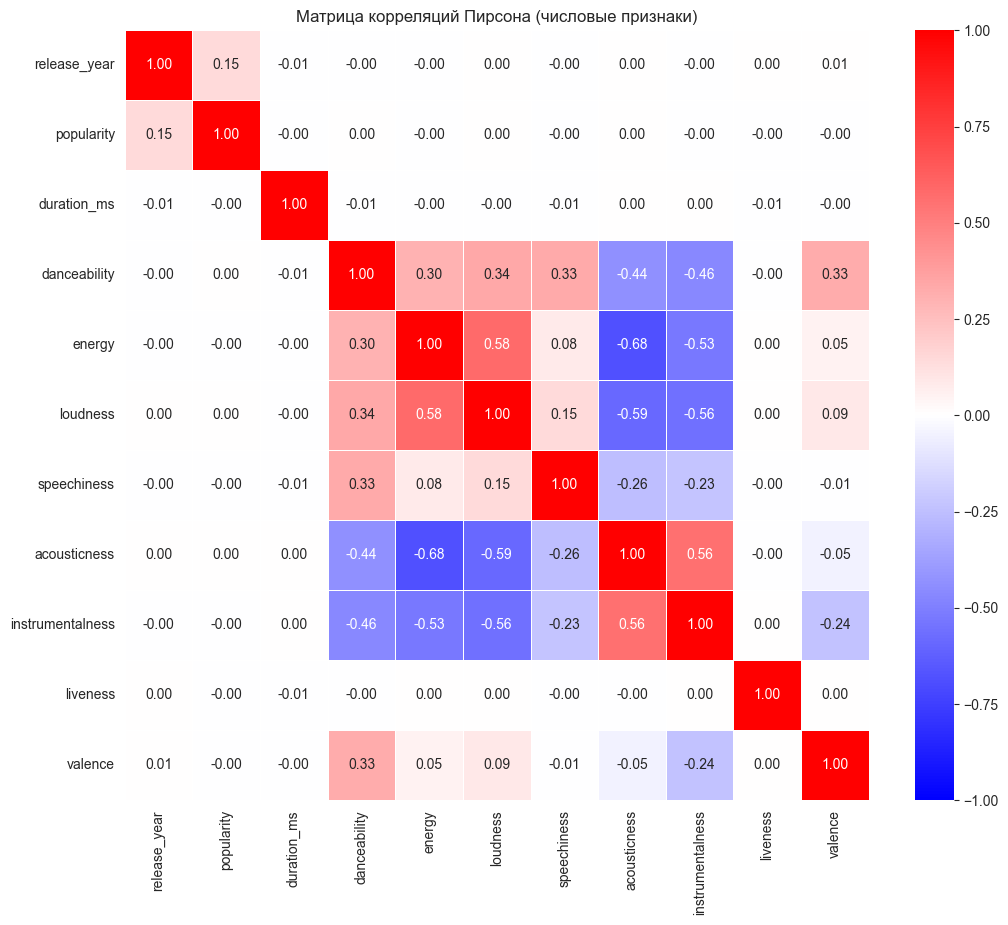

In [41]:
numeric_cols = ['release_year', 'popularity', 'duration_ms', 'danceability', 'energy', 
                'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
                'liveness', 'valence']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='bwr', linewidths=0.5, 
            vmin=-1, vmax=1, center=0)
plt.title('Матрица корреляций Пирсона (числовые признаки)')
plt.show()

10. Clustermap (иерархическая кластеризация корреляций)

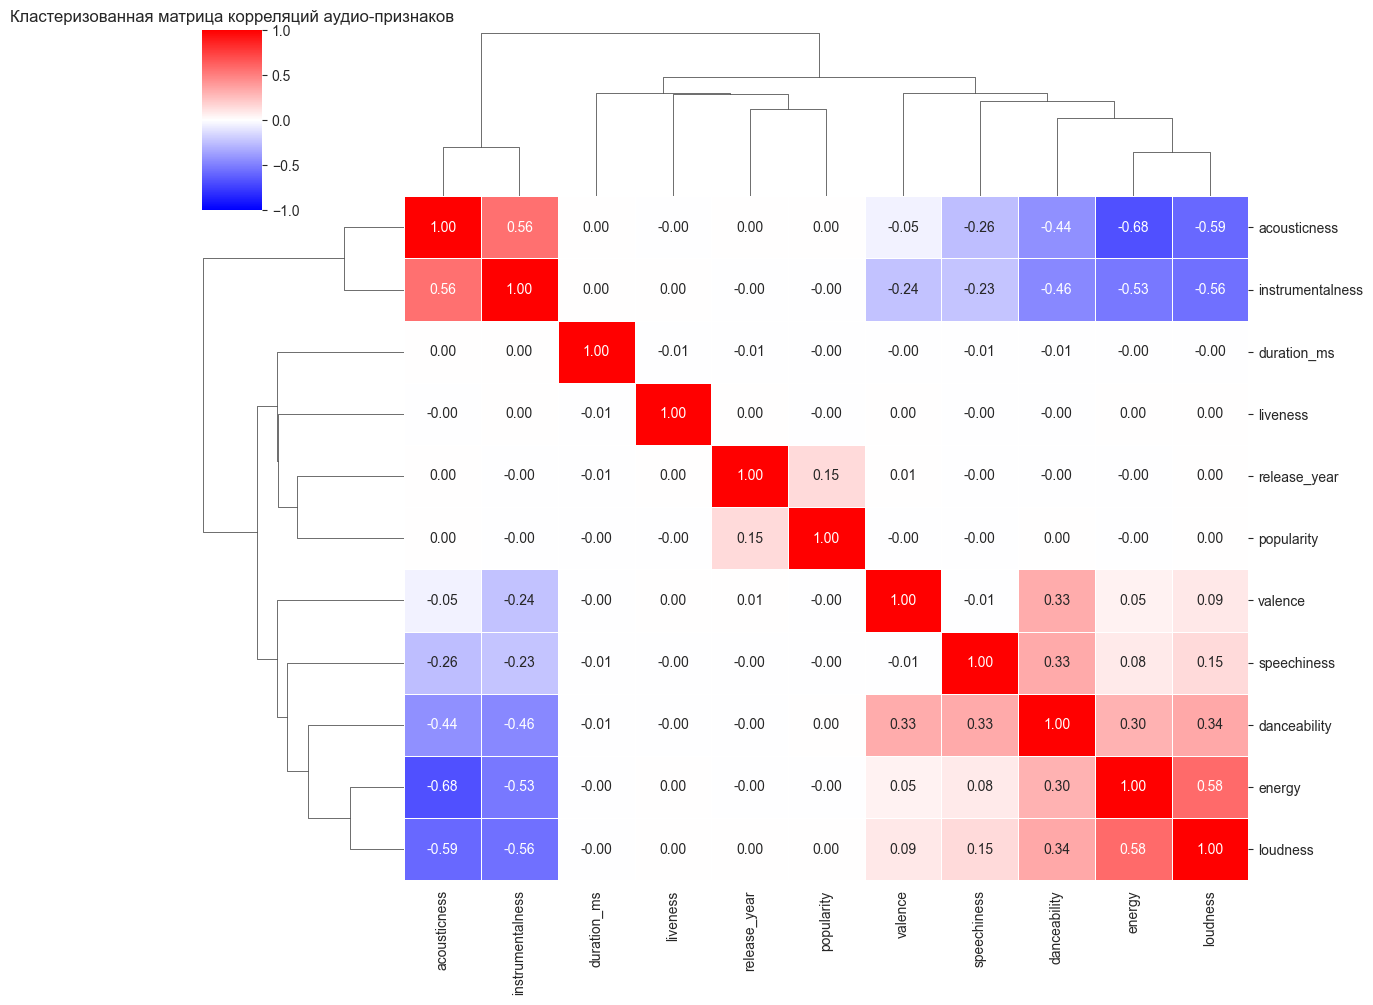

In [42]:
sns.clustermap(corr, cmap='bwr', annot=True, fmt='.2f', figsize=(12, 10),
               linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Кластеризованная матрица корреляций аудио-признаков')
plt.show()